In [1]:
import numpy as np
%pylab inline
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
np.random.seed(551) # random seed for consistency

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20).T
assert class1_sample.shape == (3,20), "The matrix has not the dimensions 3x20"

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20).T
assert class2_sample.shape == (3,20), "The matrix has not the dimensions 3x20"

In [3]:
print(class1_sample)

[[-0.39226125  0.25158405  0.74068401  1.08865703  1.34186772 -0.13234686
  -0.31865892 -0.4019165   0.87612314  1.03403683 -1.64900692  0.21918483
  -1.20805782  0.54942723 -0.20821577  3.08426403  0.74342427  0.02175409
   1.46496755 -1.88862419]
 [ 0.11983168  0.50258209 -0.78731449  0.90214393 -0.65203023  0.09709585
   0.56373196  1.02419075  0.84642014  0.05138149  0.61442609  2.39588939
  -0.92342298 -1.6655555  -0.33091737 -0.79427051  0.67292355 -2.30973777
   0.38127759  0.49747352]
 [ 1.50486434  1.20009453  0.36771168  0.18707008  0.81759763  0.49196764
  -0.48410038  0.00950407 -1.19447341 -2.13982241  0.29477035  1.47407217
   0.62492794 -0.65344273  0.64470657  0.45411268  1.76034414 -0.24619111
  -1.74761536  0.94923987]]


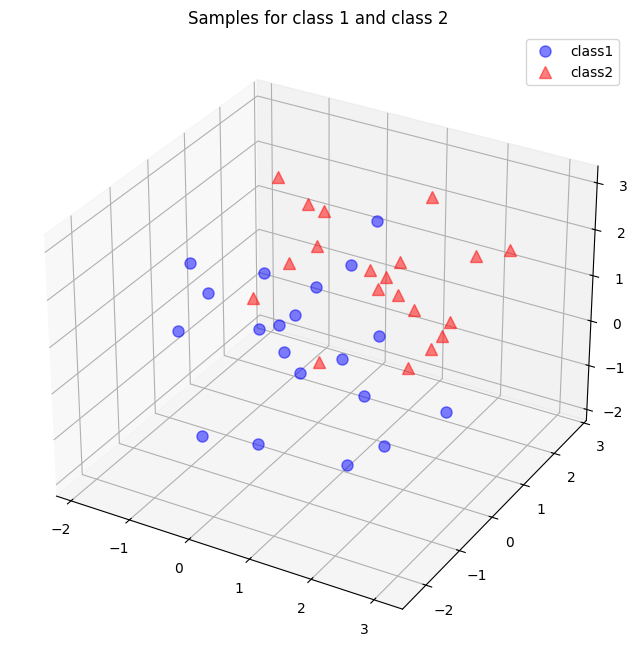

In [4]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
plt.rcParams['legend.fontsize'] = 10   
ax.plot(class1_sample[0,:], class1_sample[1,:], class1_sample[2,:], 'o', markersize=8, color='blue', alpha=0.5, label='class1')
ax.plot(class2_sample[0,:], class2_sample[1,:], class2_sample[2,:], '^', markersize=8, alpha=0.5, color='red', label='class2')

plt.title('Samples for class 1 and class 2')
ax.legend(loc='upper right')

plt.show()

In [5]:
all_samples = np.concatenate((class1_sample, class2_sample), axis=1)
assert all_samples.shape == (3,40), "The matrix has not the dimensions 3x40"

In [6]:
mean_x = np.mean(all_samples[0,:])
mean_y = np.mean(all_samples[1,:])
mean_z = np.mean(all_samples[2,:])

mean_vector = np.array([[mean_x],[mean_y],[mean_z]])

print('Mean Vector:\n', mean_vector)

Mean Vector:
 [[0.635134  ]
 [0.5480806 ]
 [0.78746925]]


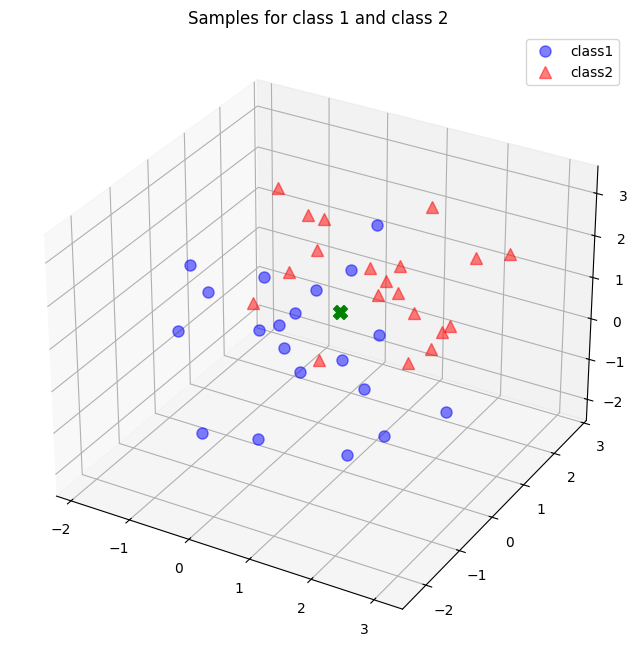

In [19]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
plt.rcParams['legend.fontsize'] = 10   
ax.plot(class1_sample[0,:], class1_sample[1,:], class1_sample[2,:], 'o', markersize=8, color='blue', alpha=0.5, label='class1')
ax.plot(class2_sample[0,:], class2_sample[1,:], class2_sample[2,:], '^', markersize=8, alpha=0.5, color='red', label='class2')

plt.title('Samples for class 1 and class 2')
ax.legend(loc='upper right')
ax.scatter(
    mean_x, mean_y, mean_z,
    color='green',
    s=100,
    marker='X',
    label='Mean'
)
plt.show()

<h3>🔹 What is a scatter matrix?</h3>

<b>A scatter matrix measures how your data points are spread out around the mean.</b>

In [7]:
scatter_matrix = np.zeros((3,3))
for i in range(all_samples.shape[1]):
    scatter_matrix += (all_samples[:,i].reshape(3,1) - mean_vector).dot((all_samples[:,i].reshape(3,1) - mean_vector).T)
print('Scatter Matrix:\n', scatter_matrix)

Scatter Matrix:
 [[45.33994277  7.96056792 -2.98895243]
 [ 7.96056792 51.33568616  6.05160175]
 [-2.98895243  6.05160175 59.16031229]]


[ <b>var_x</b>    cov_xy  cov_xz  ]

[  cov_yx   <b>var_y</b>   cov_yz ]

[  cov_zx cov_zy   <b>var_z</b>  ]


In [8]:
cov_mat = np.cov([all_samples[0,:],all_samples[1,:],all_samples[2,:]])
print('Covariance Matrix:\n', cov_mat)

Covariance Matrix:
 [[ 1.16256264  0.20411713 -0.07663981]
 [ 0.20411713  1.31629965  0.15516928]
 [-0.07663981  0.15516928  1.51693108]]


In [9]:
# eigenvectors and eigenvalues for the from the scatter matrix
eig_val_sc, eig_vec_sc = np.linalg.eig(scatter_matrix)

# eigenvectors and eigenvalues for the from the covariance matrix
eig_val_cov, eig_vec_cov = np.linalg.eig(cov_mat)

for i in range(len(eig_val_sc)):
    eigvec_sc = eig_vec_sc[:,i].reshape(1,3).T
    eigvec_cov = eig_vec_cov[:,i].reshape(1,3).T
    assert eigvec_sc.all() == eigvec_cov.all(), 'Eigenvectors are not identical'

    print('Eigenvector {}: \n{}'.format(i+1, eigvec_sc))
    print('Eigenvalue {} from scatter matrix: {}'.format(i+1, eig_val_sc[i]))
    print('Eigenvalue {} from covariance matrix: {}'.format(i+1, eig_val_cov[i]))
    print('Scaling factor: ', eig_val_sc[i]/eig_val_cov[i])
    print(40 * '-')

Eigenvector 1: 
[[-0.76160684]
 [ 0.5859315 ]
 [-0.27683803]]
Eigenvalue 1 from scatter matrix: 38.12913140754894
Eigenvalue 1 from covariance matrix: 0.977670036090999
Scaling factor:  38.99999999999998
----------------------------------------
Eigenvector 2: 
[[ 0.64103301]
 [ 0.61852157]
 [-0.45443123]]
Eigenvalue 2 from scatter matrix: 55.13983800627963
Eigenvalue 2 from covariance matrix: 1.413842000161016
Scaling factor:  39.00000000000001
----------------------------------------
Eigenvector 3: 
[[0.09503528]
 [0.52356025]
 [0.8466717 ]]
Eigenvalue 3 from scatter matrix: 62.56697180555328
Eigenvalue 3 from covariance matrix: 1.6042813283475195
Scaling factor:  39.000000000000014
----------------------------------------


<b>In Principal Component Analysis (PCA), eigenvalues and eigenvectors come from the covariance matrix of your data—and they tell you how to transform your data into a new coordinate system that captures the most important patterns.</b>

PCA tries to:

* Find new axes (directions) in your data
* These axes capture maximum variance
* Then project data onto these axes to reduce dimensions

Those axes are exactly the eigenvectors, and how important each axis is comes from the eigenvalues.

2. Where Eigenvalues & Eigenvectors Come From

You start with:

1. Center your data (subtract mean)
2. Compute covariance matrix C

Then solve:

C x v = lambda x V

C x v =lambda x v

*v = eigenvector
*lambda = eigenvalue

3. What Eigenvectors Mean in PCA

Eigenvectors = directions of maximum variance

* Each eigenvector is a principal component (PC)
* They define new axes for your data
* They are orthogonal (perpendicular) to each other

4. What Eigenvalues Mean in PCA

Eigenvalues = amount of variance in that direction

* Large eigenvalue → important direction
* Small eigenvalue → less important

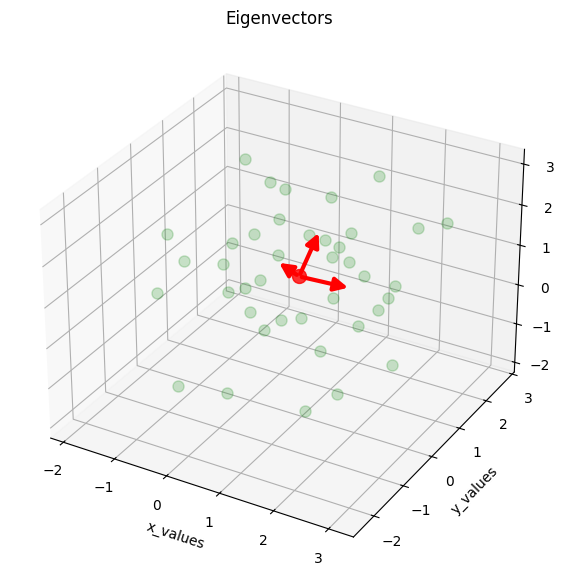

In [10]:
class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):

        super().__init__((0, 0), (0, 0), *args, **kwargs)

        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):

        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())

        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return min(zs)

    def draw(self, renderer):

        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())

        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        super().draw(renderer)

fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(111, projection='3d')

ax.plot(all_samples[0,:], all_samples[1,:], all_samples[2,:],

        'o', markersize=8, color='green', alpha=0.2)

ax.plot([mean_x], [mean_y], [mean_z],

        'o', markersize=10, color='red', alpha=0.8)

for v in eig_vec_sc.T:

    a = Arrow3D(

        [mean_x, mean_x + v[0]],

        [mean_y, mean_y + v[1]],

        [mean_z, mean_z + v[2]],

        mutation_scale=20,

        lw=3,

        arrowstyle="-|>",

        color="r"

    )

    ax.add_artist(a)

ax.set_xlabel('x_values')

ax.set_ylabel('y_values')

ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [11]:
for ev in eig_vec_sc:
    numpy.testing.assert_array_almost_equal(1.0, np.linalg.norm(ev))
    # instead of 'assert' because of rounding errors

In [12]:
# Make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_val_sc[i]), eig_vec_sc[:,i]) for i in range(len(eig_val_sc))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Visually confirm that the list is correctly sorted by decreasing eigenvalues
for i in eig_pairs:
    print(i[0])

62.56697180555328
55.13983800627963
38.12913140754894


In [13]:
matrix_w = np.hstack((eig_pairs[0][1].reshape(3,1), eig_pairs[1][1].reshape(3,1)))
print('Matrix W:\n', matrix_w)

Matrix W:
 [[ 0.09503528  0.64103301]
 [ 0.52356025  0.61852157]
 [ 0.8466717  -0.45443123]]


In [14]:
transformed = matrix_w.T.dot(all_samples)
assert transformed.shape == (2,40), "The matrix is not 2x40 dimensional."

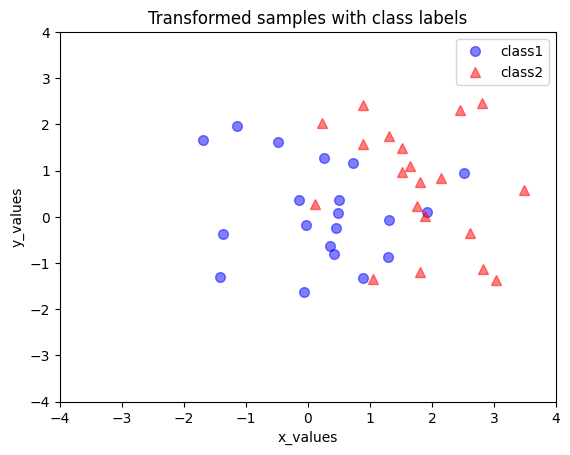

In [15]:
plt.plot(transformed[0,0:20], transformed[1,0:20], 'o', markersize=7, color='blue', alpha=0.5, label='class1')
plt.plot(transformed[0,20:40], transformed[1,20:40], '^', markersize=7, color='red', alpha=0.5, label='class2')
plt.xlim([-4,4])
plt.ylim([-4,4])
plt.xlabel('x_values')
plt.ylabel('y_values')
plt.legend()
plt.title('Transformed samples with class labels')

plt.show()